In [4]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 427.8 kB/s eta 0:00:18
   --- ------------------------------------ 0.8/8.0 MB 587.2 kB/s eta 0:00:13
   --- ------------------------------------ 0.8/8.0 MB 587.2 kB/s eta 0:00:13
   ----- ---------------------------------- 1.0/8.0 MB 657.9 kB/s eta 0:00:11
   ------ --------------------------------- 1.3/8.0 MB 706.6 kB/s eta 0:00:10
   ------ --------------------------------- 1.3/8.0 MB 706.6 kB/s eta 0:00:10
   ------- -------------------------------- 1.6/8.0 MB 711.0 kB/s eta 0:00:10
   --------- ------------------------------ 1.8/8.0 MB 722.4 kB/s eta 0:00:09
   --------- ------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Data Acquisition and Exploration

In [5]:
from sklearn.datasets import fetch_openml

In [7]:
dataset = fetch_openml("mnist_784", as_frame=False)
dataset.keys()
X, Y = dataset.data, dataset.target
type(X)
type(Y)

numpy.ndarray

In [9]:
X.shape


(70000, 784)

In [10]:
Y[0]


np.int64(5)

In [11]:
type(Y[0])


numpy.int64

In [12]:
Y = Y.astype(int)


In [13]:
Y[0]


np.int64(5)

In [14]:
Y


array([5, 0, 4, ..., 4, 5, 6], shape=(70000,))

In [15]:
Y.shape

(70000,)

# Data Splitting

In [16]:
Y_train = Y[:60000] 
Y_test = Y[60000:]
X_train = X[:60000]
X_test = X[60000:]
X[0]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18,
       126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 17

# Binary Classification

In [17]:
import numpy as np

In [18]:
np.unique_values(Y) 
Y_BIN = (Y == 5) 
Y_BIN_train = Y_BIN[:60000] 
Y_BIN_test = Y_BIN[60000:]

In [19]:
from sklearn.linear_model import SGDClassifier

In [20]:
model = SGDClassifier(random_state = 42)

In [21]:
model.fit(X_train, Y_BIN_train)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [22]:
model.predict(X_train[0].reshape(1,-1))

array([ True])

In [23]:
X_train[0].shape

(784,)

In [24]:
pred = model.predict(X_train)

In [25]:
pred[:20]

array([ True, False, False, False, False, False, False, False, False,
       False, False,  True, False, False, False, False, False, False,
       False, False])

In [26]:
Y[:20]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 5, 3, 6, 1, 7, 2, 8, 6, 9])

# Performance Metrics

In [27]:
from sklearn.metrics import confusion_matrix

In [28]:
confusion_matrix(Y_BIN_train, pred)

array([[52316,  2263],
       [  601,  4820]])

In [29]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score

In [30]:
precision_score(Y_BIN_train, pred)

0.6805026118876183

In [31]:
recall_score(Y_BIN_train, pred)

0.8891348459693783

In [32]:
accuracy_score(Y_BIN_train, pred)

0.9522666666666667

In [33]:
f1_score(Y_BIN_train, pred)

0.7709532949456174

# Logistic Regression Visualization

In [34]:
x = np.linspace(-6, 6, num=1000)

In [36]:
import matplotlib.pyplot as plt

In [37]:
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, 'Sigmoid Function')

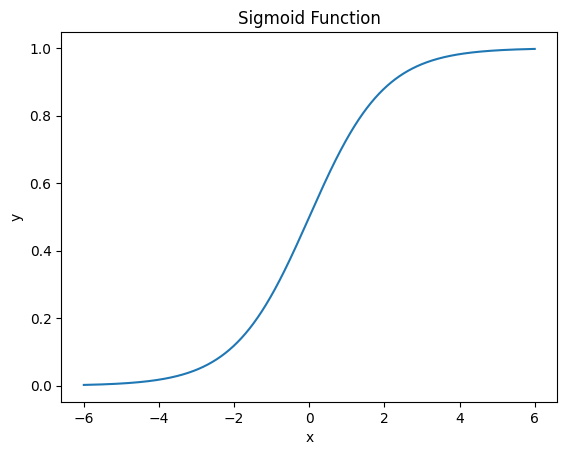

In [39]:
plt.plot(x, (1 / (1 + np.exp(-x))))
plt.xlabel("x")
plt.ylabel("y")
plt.title("Sigmoid Function")

In [40]:
import os
print(os.getcwd())

C:\Users\sdaks
